# Cinemática inversa estocástica para un robot 2D

Este cuaderno implementa y explica un flujo de **cinemática inversa estocástica** para un **robot planar de 2 grados de libertad (2D)**
## Objetivos
- Describir y ejecutar los pasos para resolver la **cinemática inversa** co un enfoque estocástico/aleatorizado.

## Contenidos
1. **Importaciones y configuración**
2. **Definición de funciones y clases**
3. **Probar la cinemática directa (FK, Forward Kinematics)**
4. **Construir y desplegar el espacio potencial del problema**
5. **Resolver la cinemática inversa**

## Requisitos
- Python 3.x
- `numpy`, `matplotlib`

## Cómo usar este notebook
1. Ejecuta las celdas en orden.
2. Lee las celdas *Markdown* que anteceden a cada bloque de código.
3. Ajusta parámetros en las celdas de configuración.

## Notación
- $\theta = [\theta_1, \theta_2]$ : vector articular (rad)
- $L = [L_1, L_2]$ : longitudes de eslabones
- $(x,y)$ : objetivo en el plano

## Autor
Dr. Juan Mauel Ahuactzin Larios


### 1 Importaciones y configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import math
import random
import sys

sys.path.append("..")

from common.homtransf import *
from common.robot_2D import *

print("Python version")
print (sys.version)

# Make numpy values easier to read.
np.set_printoptions(precision=3, suppress=True)

Python version
3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]


### 2 Definición de funciones y clases

In [2]:
def distance(x_goal, y_goal, x, y):
    distance = math.sqrt((x_goal-x)**2 + (y_goal-y)**2)
    return distance

def draw_goal(x, y, ax=None):
    if ax is None:
        ax = plt.gca()   # usa el eje actual

    ax.scatter(x, y, marker='+')

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_2D_potential_graph(X_mesh, Y_mesh, Z_mesh, ax=None, points=None):
    created_fig = False

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        created_fig = True

    h = ax.contourf(X_mesh, Y_mesh, Z_mesh)
    ax.set_aspect('equal')

    ax.set_xlabel('theta 1')
    ax.set_ylabel('theta 2')
    ax.set_title('2D distance surface')

    # ---- Dibujar puntos opcionales ----
    if points is not None:
        for (x, y) in points:
            ax.scatter(
                x, y,
                s=80,               # tamaño del círculo
                c='red',            # color
                edgecolors='black',
                zorder=5            # por encima del contour
            )

    if created_fig:
        plt.colorbar(h, ax=ax)
        plt.show()

def plot_3D_potential_graph(X_mesh, Y_mesh, Z_mesh, ax=None):
    created_fig = False

    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(projection='3d')
        created_fig = True

    surf = ax.plot_surface(
        X_mesh, Y_mesh, Z_mesh,
        rstride=1, cstride=1,
        cmap='viridis',
        edgecolor='none'
    )

    ax.set_title('3D distance surface')
    ax.set_xlabel('theta 1')
    ax.set_ylabel('theta 2')
    ax.set_zlabel('distance')

    if created_fig:
        plt.show()

Enseguida se implementa un método iterativo que resuelve el problema cinemático inverso para el robot que se muestra en la figura. El elemento terminal del robot debe ser colocado en las cordenadas $x_{goal},y_{goal}$. ¿Qué valores aticulares del robot ($\theta_1, \theta_2$) lo colocan en dicha posición?

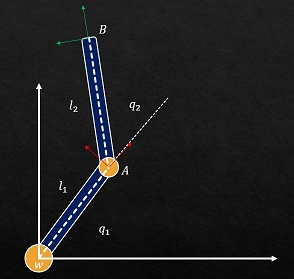

Supón que los valores de $l_1$ y $l_2$ son iguales a 10.

### 3 Probar la cinamática directa (FK, Forward Kinematics)

Theta 1:  -0.7853981633974483 Theta 2:  0.7853981633974483


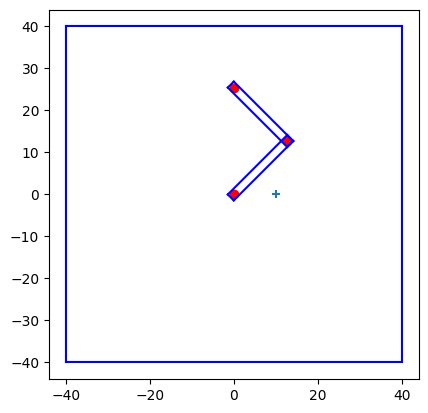

Distance to goal:  27.349588662354687


In [4]:
l = 20
w = 2

theta_1 = -math.pi/4
theta_2 = math.pi/4

x_goal = 0.5*l
y_goal = 0

my_robot = PlanarRobot(l, w)
print("Theta 1: ",theta_1, "Theta 2: ", theta_2)

theta_1 = pi/4
theta_2 = pi/2
my_robot.set_conf([theta_1, theta_2])
x_gripper, y_gripper = my_robot.direct_kinematics()

my_robot.draw()
draw_goal(x_goal, y_goal)
plt.show()

print("Distance to goal: ", distance(x_goal, y_goal, x_gripper, y_gripper))

In [5]:
# Output area
out = widgets.Output()

# Sliders
x_slider = widgets.FloatSlider(
    value=0.0, min=-2*l, max=2*l, step=(4*l)/200,
    description="x_goal", continuous_update=False
)

y_slider = widgets.FloatSlider(
    value=0.0, min=-2*l, max=2*l, step=(4*l)/200,
    description="y_goal", continuous_update=False
)

theta1_slider = widgets.FloatSlider(
    value=0.0, min=0, max=359, step=1,
    description="θ1 (deg)", continuous_update=False
)

theta2_slider = widgets.FloatSlider(
    value=0.0, min=0, max=359, step=1,
    description="θ2 (deg)", continuous_update=False
)


def update_plot(x_goal_f, y_goal_f, deg_theta1, deg_theta2):
    global x_goal, y_goal
    with out:
        clear_output(wait=True)

        theta1 = np.deg2rad(deg_theta1)
        theta2 = np.deg2rad(deg_theta2)
        x_goal = x_goal_f
        y_goal = y_goal_f

        # Configurar robot
        my_robot.set_conf([theta1, theta2])
        x_gripper, y_gripper = my_robot.direct_kinematics()

        # Calcular distancia
        dist = distance(x_goal, y_goal, x_gripper, y_gripper)

        # Dibujar (usa la firma correcta de tu draw)
        # Si tu draw usa los thetas como argumentos:
        my_robot.draw()
        # (si tu draw NO requiere argumentos, cambia la línea anterior por my_robot.draw())

        draw_goal(x_goal, y_goal)

        # plt.legend([f"Distance: {dist:.3f} | θ(deg)=({deg_theta1:.0f},{deg_theta2:.0f}) | θ(rad)=({theta1:.3f},{theta2:.3f})"])
        plt.title(f"Distance: {dist:.3f} | θ(rad)=({theta1:.3f},{theta2:.3f})")
        plt.show()


ui = widgets.VBox([
    widgets.HBox([x_slider, y_slider]),
    widgets.HBox([theta1_slider, theta2_slider]),
    out
])

display(ui)

# Conectar sliders: los nombres deben coincidir con los parámetros de update_plot
widgets.interactive_output(
    update_plot,
    {
        "x_goal_f": x_slider,
        "y_goal_f": y_slider,
        "deg_theta1": theta1_slider,
        "deg_theta2": theta2_slider
    }
)

# Dibujo inicial
update_plot(
    x_slider.value,
    y_slider.value,
    theta1_slider.value,
    theta2_slider.value
)


### 4 Construir y desplegar el espacio potencial del problema

#### Construir el espacio potencial del problema

In [6]:
grille_size = 100
n_random = 100

# 50 pares (x,y) aleatorios en [0, 2π]
i_random = np.random.randint(0, grille_size, size=n_random)
j_random = np.random.randint(0, grille_size, size=n_random)

i_j_pairs = list(zip(i_random, j_random))

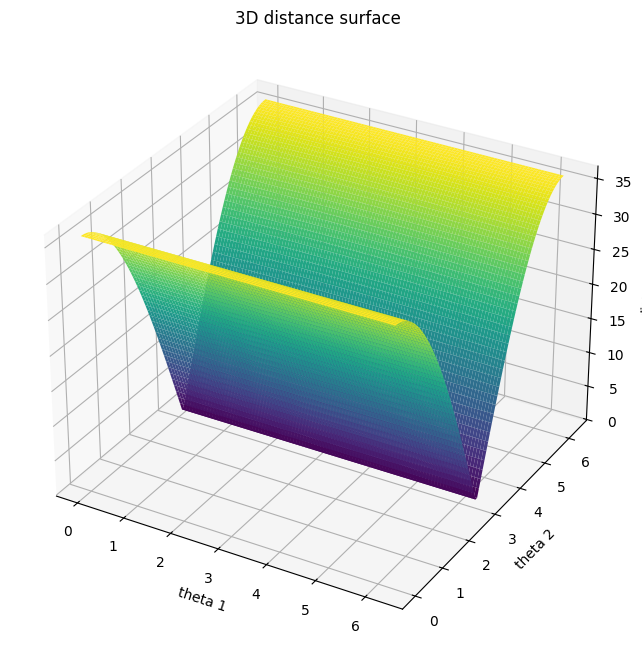

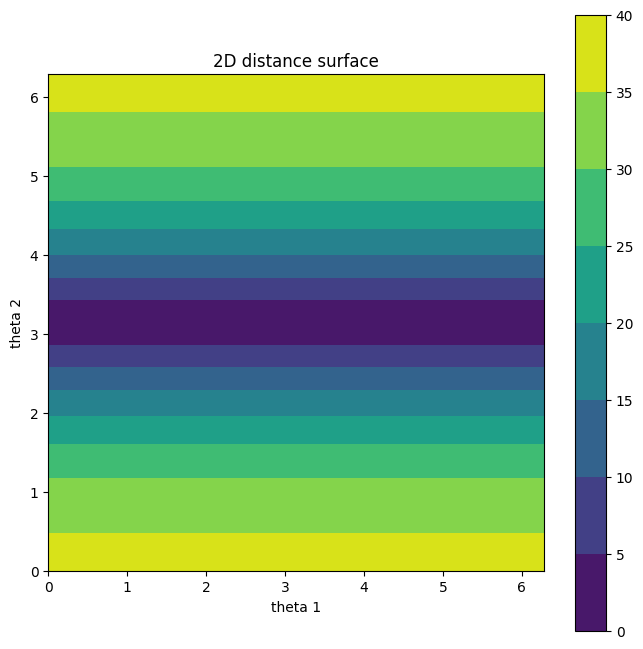

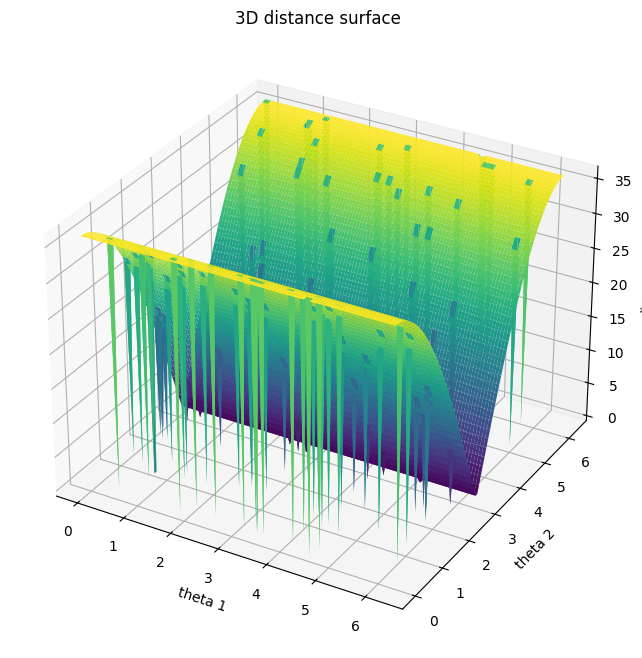

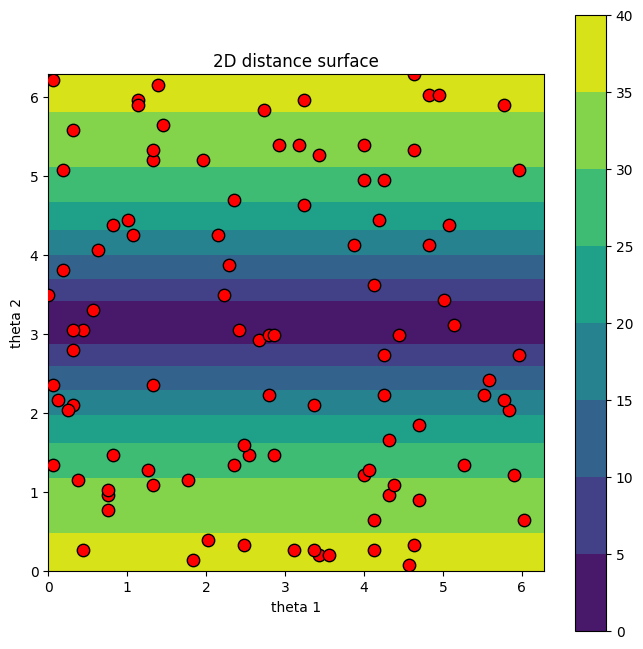

In [7]:
t1_values = np.linspace(0, 2*math.pi, grille_size)
t2_values = np.linspace(0, 2*math.pi, grille_size)

t1_mesh, t2_mesh = np.meshgrid(t1_values, t2_values, indexing='ij')
dist_mesh = np.zeros(t1_mesh.shape)

i = 0
for t1 in t1_values:
    j = 0
    for t2 in t2_values:
        my_robot.set_conf([t1, t2])
        dist_mesh[i,j] = distance(*my_robot.direct_kinematics(), x_goal, y_goal)
        j = j+1
    i = i+1

pairs = [[t1_values[i], t2_values[j]] for i, j in i_j_pairs]

plot_3D_potential_graph(t1_mesh, t2_mesh, dist_mesh)
plot_2D_potential_graph(t1_mesh, t2_mesh, dist_mesh)

for (i, j) in i_j_pairs:
    dist_mesh[i,j] = 0

plot_3D_potential_graph(t1_mesh, t2_mesh, dist_mesh)
plot_2D_potential_graph(t1_mesh, t2_mesh, dist_mesh, ax=None, points=pairs)

### 5 Resolver la cinemática inversa


#### Mostrar la configuración inicial y su distancia al punto objetivo del elemento terminal

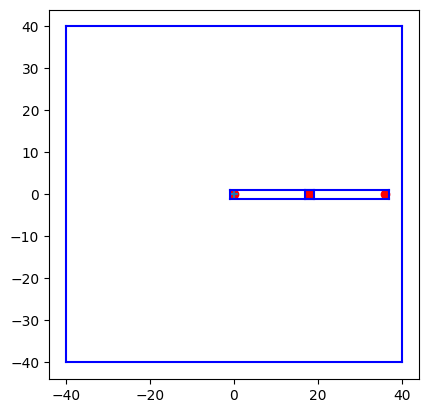

Best distance:  36.0


In [8]:
best_theta_1 = 0.0
best_theta_2 = 0.0
my_robot.set_conf([best_theta_1, best_theta_2])
best_distance = distance(*my_robot.direct_kinematics(), x_goal, y_goal)

my_robot.draw()
draw_goal(x_goal, y_goal)
plt.show()

print("Best distance: ", best_distance )

#### Resolver el problema por medio de un método estocástico
Cambia los valores de las variables 

```python
max_dividend
number_of_points
```
pare explorar diferentes comportamientos del algoritmo.


Best distance: 36.0
Best distance: 15.709654544319227 with (1.7975292974114465, -2.2384513343761827)-->(102.99084229279202,-128.25381410518267)
Best distance: 12.147689343992024 with (4.900316196213747, -2.453209424517314)-->(280.7674363226491,-140.5585462865596)
Best distance: 0.5414195667532167 with (5.400705468392241, -3.1115126547591068)-->(309.4376297320998,-178.2765430192432)
Best distance: 0.1820734351651961 with (5.821362829738224, -3.1517078875560025)-->(333.53952115833425,-180.57956021505117)
Best distance: 0.07050928071615441 with (6.467685731804983, -3.1376754688233435)-->(370.5710956494068,-179.77556184530948)
Best distance: 0.009224018992501958 with (6.6662086003346515, -3.1421050990949837)-->(381.9456181529873,-180.02936096467786)
Best distance: 0.007569425779185589 with (6.467906873286905, -3.142013177247291)-->(370.5837661229962,-180.02409423076003)
Best distance: 0.003032060725456088 with (5.98509302261624, -3.1417611014080733)-->(342.92057018910754,-180.0096513490556

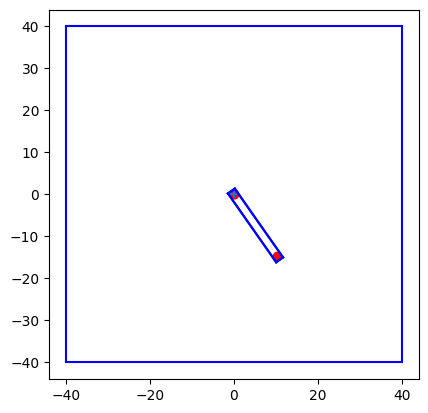

In [9]:
print(f"Best distance: {best_distance}")

max_dividend = 100
number_of_points = 1000

# max_dividend denota que tan fino queremos buscar la solucion entre más grande n 
# buscamos en una vecindad más pequeña
for n in range(1,max_dividend):
    # Generamos los puntos aleatorios
    for i in range(number_of_points):
        ## Buscamos al rededor de la mejor solución haciendo cada vez mas pequeña la vecindada por medio de n
        theta_1 = random.uniform(best_theta_1-math.pi/n, best_theta_1+math.pi/n)
        theta_2 = random.uniform(best_theta_2-math.pi/n, best_theta_2+math.pi/n)
        my_robot.set_conf([theta_1, theta_2])
        dist = distance(*my_robot.direct_kinematics(), x_goal, y_goal)
        if (dist < best_distance):
            best_distance = dist
            best_theta_1 = theta_1
            best_theta_2 = theta_2
            print(f"Best distance: {best_distance} with ({best_theta_1}, {best_theta_2})-->({np.rad2deg(best_theta_1)},{np.rad2deg(best_theta_2)})")

my_robot.set_conf([best_theta_1, best_theta_2])
my_robot.draw()
draw_goal(x_goal, y_goal)
plt.show()

In [10]:
t1_mesh, t2_mesh = np.meshgrid(t1_values, t2_values, indexing="ij")

out = widgets.Output()

x_slider = widgets.FloatSlider(
    value=0.0, min=-2*l, max=2*l, step=(4*l)/200,
    description="x_goal", continuous_update=False
)
y_slider = widgets.FloatSlider(
    value=0.0, min=-2*l, max=2*l, step=(4*l)/200,
    description="y_goal", continuous_update=False
)

def compute_dist_mesh(x_goal, y_goal):
    dist_mesh = np.zeros(t1_mesh.shape, dtype=float)
    for i, t1 in enumerate(t1_values):
        for j, t2 in enumerate(t2_values):
            my_robot.set_conf([t1, t2])
            dist_mesh[i, j] = distance(*my_robot.direct_kinematics(), x_goal, y_goal)
    return dist_mesh

def redraw(x_goal, y_goal):
    with out:
        clear_output(wait=True)

        fig = plt.figure(figsize=(18, 5))

        # --- Subplot 1: Robot ---
        ax1 = fig.add_subplot(1, 3, 1)
        my_robot.set_conf([0, 0])
        my_robot.draw(ax=ax1)
        draw_goal(x_goal, y_goal, ax=ax1)
        ax1.set_title("Robot")

        # --- Subplot 2: Potencial 3D ---
        ax2 = fig.add_subplot(1, 3, 2, projection='3d')
        dist_mesh = compute_dist_mesh(x_goal, y_goal)
        plot_3D_potential_graph(t1_mesh, t2_mesh, dist_mesh, ax=ax2)
        ax2.set_title("Potential 3D")

        # --- Subplot 3: Potencial 2D ---
        ax3 = fig.add_subplot(1, 3, 3)
        plot_2D_potential_graph(t1_mesh, t2_mesh, dist_mesh, ax=ax3)
        ax3.set_title("Potential 2D")

        plt.tight_layout()
        plt.show()

def on_slider_change(change):
    # change['name'] == 'value' cuando cambia el valor
    redraw(x_slider.value, y_slider.value)

# Conectar eventos
x_slider.observe(on_slider_change, names='value')
y_slider.observe(on_slider_change, names='value')

ui = widgets.VBox([
    widgets.HBox([x_slider, y_slider]),
    out
])

display(ui)

# Dibujo inicial
redraw(x_slider.value, y_slider.value)

